# AlgoSense AI

## 1. Agent concept

| Item | Description |
|------|-------------|
| **Name** | AlgoSense AI |
| **Role** | LeetCode interview prep learning agent |
| **Input** | User learning state (weakness by category, solved/wrong history, review priority), plus MCQ selections for category and Big-O (time + space) |
| **Output 1** | Curated next problem + problem card (summary, tags, patterns, what to answer) |
| **Output 2** | Evaluation results (category + Big-O), best-solution guidance, mistake diagnosis, weakness updates, and review scheduling decisions |

## 2. Target graph (full design)

```
[START]
   |
   v
[Problem Curation Node]
(interview frequency + weaknesses + review priority)
   |
   v
[Problem Card Generator]
   |
   v
[Category Answer Intake]
   |
   v
[Category Evaluation]
   |
   v
[Best Solution Presenter]
   |
   v
[Big-O Answer Intake]
   |
   v
[Big-O Evaluation]
   |
   v
[Mistake Diagnosis]
   |
   v
[Weakness Tracker]
   |
   v
[Spaced Repetition Scheduler]
   |
   +----------------------+
   |                      |
   v                      v
[Wrong Note Update]   [Next Problem Selector]
   |                      |
   +----------+-----------+
              |
              v
[Update User Learning State]
              |
              v
[Continue Session?]
     |        |
    Yes       No
     |        |
     v        v
[Problem Curation Node] [END]
```

**Custom state** (`TypedDict`, not `MessagesState`). Intake nodes are MCQ by design for UI integration.


## 3. Runnable sample

End-to-end invocation lives in the **final run cell** of this notebook (requires `OPENAI_API_KEY` in the environment).

## Design (short)

### Custom state (TypedDict)
This notebook uses a **custom `TypedDict` state** (`LearningState`). Each node reads the current state and returns a partial update.

Core fields:
- `user_profile`: `weakness_by_category`, `solved_ids`, `wrong_ids`
- `due_review_ids`: review priority IDs (spaced repetition input)
- `problem_pool`: LLM-generated LeetCode candidates (strict JSON)
- `selected_problem`: the curated problem for this session turn
- `problem_card`: a UI-ready card for the selected problem

MCQ / evaluation fields:
- `category_mcq`, `category_selected_index`, `category_selected`, `expected_category`, `category_is_correct`
- `best_solution`, `expected_bigo_time`, `expected_bigo_space`
- `bigo_mcq_time`, `bigo_mcq_space`, `bigo_selected_time_index`, `bigo_selected_space_index`, `bigo_selected_time`, `bigo_selected_space`, `bigo_is_correct`
- `mistake_diagnosis`

### Nodes (inputs → outputs)
- **Problem Pool Generator (LLM)**: `user_profile` → `problem_pool`
- **Problem Curation (scoring)**: `problem_pool`, `user_profile`, `due_review_ids` → `selected_problem`
- **Problem Card Generator (LLM)**: `selected_problem`, `user_profile` → `problem_card`
- **Category Answer Intake (MCQ)**: `selected_problem` (+ `category_selected_index`) → `category_mcq`, `category_selected`
- **Category Evaluation (LLM)**: `selected_problem`, `category_selected` → `expected_category`, `category_is_correct`
- **Best Solution Presenter (LLM)**: `selected_problem` → `best_solution`, `expected_bigo_time`, `expected_bigo_space`
- **Big-O Answer Intake (MCQ)**: expected Big-O (+ selected indices) → `bigo_mcq_time`, `bigo_mcq_space`, selected answers
- **Big-O Evaluation (objective)**: selected vs expected → `bigo_is_correct`
- **Mistake Diagnosis (LLM)**: (if wrong) state snapshot → `mistake_diagnosis`
- **Weakness Tracker**: correctness signals + problem categories → updated `user_profile.weakness_by_category`

### How MCQ works in the notebook
The intake nodes are **multiple-choice by design** for easy UI integration.

- In a UI: render `*_mcq['options']`, store the clicked index back into state.
- In this notebook: we **simulate** user choices by setting:
  - `category_selected_index`
  - `bigo_selected_time_index`
  - `bigo_selected_space_index`



In [ ]:
from __future__ import annotations

import json
import os
import random
from typing import Any, Dict, List, Optional, TypedDict

from langchain.chat_models import init_chat_model
from langgraph.graph import END, START, StateGraph


# Heavily-used LLM for this workflow
llm = init_chat_model("openai:gpt-4o")


CANONICAL_CATEGORIES = [
    "array",
    "hashmap",
    "two_pointers",
    "stack",
    "graph",
    "dfs_bfs",
    "dp",
    "greedy",
    "binary_search",
    "sorting",
]

BIG_O_CHOICES = [
    "O(1)",
    "O(log n)",
    "O(n)",
    "O(n log n)",
    "O(n^2)",
    "O(n^3)",
    "O(2^n)",
]


class Problem(TypedDict):
    id: str
    title: str
    slug: str
    url: str
    categories: List[str]
    difficulty: str  # Easy/Medium/Hard
    interview_freq: float  # 0~1 (LLM-estimated proxy)


class UserProfile(TypedDict):
    weakness_by_category: Dict[str, float]  # higher = weaker
    solved_ids: List[str]
    wrong_ids: List[str]


class LearningState(TypedDict, total=False):
    user_profile: UserProfile
    due_review_ids: List[str]

    # produced by LLM
    problem_pool: List[Problem]

    # produced by curation
    selected_problem: Problem

    # produced by LLM
    problem_card: Dict[str, Any]

    # Category MCQ
    category_mcq: Dict[str, Any]  # {prompt, options: [...]} 
    category_selected_index: int
    category_selected: str
    expected_category: str
    category_is_correct: bool

    # Best solution + expected Big-O
    best_solution: Dict[str, Any]
    expected_bigo_time: str
    expected_bigo_space: str

    # Big-O MCQ
    bigo_mcq_time: Dict[str, Any]
    bigo_mcq_space: Dict[str, Any]
    bigo_selected_time_index: int
    bigo_selected_space_index: int
    bigo_selected_time: str
    bigo_selected_space: str
    bigo_is_correct: bool

    # Post-analysis
    mistake_diagnosis: Dict[str, Any]


In [20]:
DEFAULT_PROFILE: UserProfile = {
    "weakness_by_category": {
        "hashmap": 0.6,
        "two_pointers": 0.9,
        "stack": 0.2,
        "graph": 0.7,
        "dfs_bfs": 0.7,
        "array": 0.3,
        "sorting": 0.4,
    },
    "solved_ids": [],
    "wrong_ids": ["lc_20_valid_parentheses"],
}


def _require_openai_key() -> None:
    if not os.getenv("OPENAI_API_KEY"):
        raise RuntimeError(
            "OPENAI_API_KEY is not set. Put it in your environment (recommended) or in a local .env file."
        )


def _json_from_llm(text: str) -> Any:
    """Extract JSON from an LLM response (supports fenced or plain JSON)."""
    s = text.strip()
    if "```" in s:
        # take the first fenced block
        parts = s.split("```")
        if len(parts) >= 3:
            s = parts[1].strip()
            if s.startswith("json"):
                s = s[4:].strip()
    return json.loads(s)


def generate_problem_pool_node(state: LearningState) -> LearningState:
    """Generate a fresh candidate pool via LLM (no hand-written sample pool)."""

    _require_openai_key()

    profile = state.get("user_profile", DEFAULT_PROFILE)
    weakness = profile.get("weakness_by_category", {})
    solved = profile.get("solved_ids", [])

    prompt = {
        "role": "user",
        "content": (
            "Generate a candidate pool of 12 LeetCode problems as STRICT JSON. "
            "Focus on interview-popular problems, but bias toward the user's weak categories.\n\n"
            f"User weakness_by_category (higher=weaker): {weakness}\n"
            f"Already solved ids (avoid repeating): {solved}\n\n"
            "Return ONLY valid JSON: an array of objects with fields:\n"
            "- id: stable string id (e.g., 'lc_two_sum')\n"
            "- title\n"
            "- slug (leetcode slug, e.g., 'two-sum')\n"
            "- url (https://leetcode.com/problems/<slug>/)\n"
            "- categories (array of canonical tags like: array, hashmap, two_pointers, stack, graph, dfs_bfs, dp, greedy, binary_search, sorting)\n"
            "- difficulty (Easy|Medium|Hard)\n"
            "- interview_freq (float 0..1, your estimate as a proxy for popularity)\n\n"
            "Rules:\n"
            "- Do not include explanations, markdown, or extra keys.\n"
            "- Ensure slugs and urls are consistent.\n"
        ),
    }

    resp = llm.invoke([prompt])
    pool = _json_from_llm(getattr(resp, "content", str(resp)))

    if not isinstance(pool, list) or not pool:
        raise ValueError("LLM returned an empty/non-list problem pool")

    # minimal validation / normalization
    normalized: List[Problem] = []
    for item in pool:
        if not isinstance(item, dict):
            continue
        if not all(k in item for k in ["id", "title", "slug", "url", "categories", "difficulty", "interview_freq"]):
            continue
        item["interview_freq"] = float(item["interview_freq"])
        normalized.append(item)  # type: ignore[arg-type]

    if not normalized:
        raise ValueError("LLM returned pool, but none passed validation")

    return {**state, "user_profile": profile, "problem_pool": normalized}


In [21]:
def _weakness_score(problem: Problem, weakness_by_category: Dict[str, float]) -> float:
    if not problem.get("categories"):
        return 0.0
    vals = [float(weakness_by_category.get(cat, 0.0)) for cat in problem["categories"]]
    return sum(vals) / max(1, len(vals))


def problem_curation_node(state: LearningState) -> LearningState:
    """Pick the next problem from the LLM-generated pool using transparent scoring."""

    profile = state.get("user_profile", DEFAULT_PROFILE)
    pool = state["problem_pool"]  # generated by LLM node
    due_ids = set(state.get("due_review_ids", []))
    solved = set(profile.get("solved_ids", []))

    best: Optional[Problem] = None
    best_score = -1e9

    for p in pool:
        if p["id"] in solved:
            continue

        freq = float(p.get("interview_freq", 0.0))
        weak = _weakness_score(p, profile.get("weakness_by_category", {}))
        due = 1.0 if p["id"] in due_ids else 0.0

        # MVP weights (easy to explain)
        score = 0.50 * freq + 0.35 * weak + 0.15 * due

        if score > best_score:
            best_score = score
            best = p

    if best is None:
        best = pool[0]

    return {**state, "selected_problem": best}


In [22]:
def _pick_mcq_options(correct: str, universe: List[str], k: int = 4) -> List[str]:
    if correct not in universe:
        universe = [correct] + universe
    distractors = [x for x in universe if x != correct]
    random.shuffle(distractors)
    options = [correct] + distractors[: max(0, k - 1)]
    random.shuffle(options)
    return options


def category_answer_intake_node(state: LearningState) -> LearningState:
    """Multiple-choice category question.

    In a real UI, you would render options and collect the user's choice.
    In this notebook, set `category_selected_index` in the initial state to simulate.
    """

    p = state["selected_problem"]

    # Use the problem's tags as a strong prior for the correct category,
    # but still present a standardized MCQ.
    correct_hint = p["categories"][0] if p.get("categories") else "array"
    options = _pick_mcq_options(correct_hint, CANONICAL_CATEGORIES, k=5)

    mcq = {
        "prompt": f"Select the best primary solution category for: {p['title']}",
        "options": options,
    }

    idx = int(state.get("category_selected_index", 0))
    idx = max(0, min(idx, len(options) - 1))
    selected = options[idx]

    return {**state, "category_mcq": mcq, "category_selected": selected}


def category_evaluation_node(state: LearningState) -> LearningState:
    """Evaluate the chosen category using the LLM (objective judgement)."""

    _require_openai_key()

    p = state["selected_problem"]
    selected = state["category_selected"]

    prompt = {
        "role": "user",
        "content": (
            "You are evaluating a candidate's solution CATEGORY choice for a LeetCode interview question.\n\n"
            f"Problem: {p}\n\n"
            f"Candidate selected category: {selected}\n\n"
            "Return ONLY strict JSON with keys:\n"
            "- expected_category: one of [array, hashmap, two_pointers, stack, graph, dfs_bfs, dp, greedy, binary_search, sorting]\n"
            "- is_correct: boolean\n"
            "- brief_reason: one sentence\n"
        ),
    }

    resp = llm.invoke([prompt])
    out = _json_from_llm(getattr(resp, "content", str(resp)))

    expected = str(out.get("expected_category", ""))
    is_correct = bool(out.get("is_correct", False))

    return {
        **state,
        "expected_category": expected,
        "category_is_correct": is_correct,
        "mistake_diagnosis": {
            "category": {
                "selected": selected,
                "expected": expected,
                "reason": out.get("brief_reason", ""),
            }
        },
    }


def best_solution_presenter_node(state: LearningState) -> LearningState:
    """Present the best solution and define the expected Big-O (time+space)."""

    _require_openai_key()

    p = state["selected_problem"]

    prompt = {
        "role": "user",
        "content": (
            "Provide the best (interview-optimal) approach for the LeetCode problem below.\n\n"
            f"Problem: {p}\n\n"
            "Return ONLY strict JSON with keys:\n"
            "- approach_name\n"
            "- high_level_steps (array of 4-7 short steps)\n"
            "- key_data_structures (array)\n"
            "- expected_time_bigo (one of: O(1), O(log n), O(n), O(n log n), O(n^2), O(n^3), O(2^n))\n"
            "- expected_space_bigo (one of the same set)\n"
            "- why_this_is_optimal (1-2 sentences)\n"
        ),
    }

    resp = llm.invoke([prompt])
    out = _json_from_llm(getattr(resp, "content", str(resp)))

    time_bigo = str(out.get("expected_time_bigo", ""))
    space_bigo = str(out.get("expected_space_bigo", ""))

    return {
        **state,
        "best_solution": out,
        "expected_bigo_time": time_bigo,
        "expected_bigo_space": space_bigo,
    }


def bigo_answer_intake_node(state: LearningState) -> LearningState:
    """Multiple-choice intake for BOTH time and space Big-O."""

    expected_t = state.get("expected_bigo_time", "O(n)")
    expected_s = state.get("expected_bigo_space", "O(n)")

    time_options = _pick_mcq_options(expected_t, BIG_O_CHOICES, k=5)
    space_options = _pick_mcq_options(expected_s, BIG_O_CHOICES, k=5)

    time_mcq = {
        "prompt": "Select the expected TIME complexity of the optimal solution:",
        "options": time_options,
    }
    space_mcq = {
        "prompt": "Select the expected SPACE complexity of the optimal solution:",
        "options": space_options,
    }

    ti = int(state.get("bigo_selected_time_index", 0))
    si = int(state.get("bigo_selected_space_index", 0))

    ti = max(0, min(ti, len(time_options) - 1))
    si = max(0, min(si, len(space_options) - 1))

    return {
        **state,
        "bigo_mcq_time": time_mcq,
        "bigo_mcq_space": space_mcq,
        "bigo_selected_time": time_options[ti],
        "bigo_selected_space": space_options[si],
    }


def _normalize_bigo(s: str) -> str:
    return str(s).replace(" ", "").lower()


def bigo_evaluation_node(state: LearningState) -> LearningState:
    """Objective evaluation of Big-O answers (exact match after normalization)."""

    expected_t = _normalize_bigo(state.get("expected_bigo_time", ""))
    expected_s = _normalize_bigo(state.get("expected_bigo_space", ""))
    got_t = _normalize_bigo(state.get("bigo_selected_time", ""))
    got_s = _normalize_bigo(state.get("bigo_selected_space", ""))

    ok = (expected_t == got_t) and (expected_s == got_s)

    return {
        **state,
        "bigo_is_correct": ok,
    }


def mistake_diagnosis_node(state: LearningState) -> LearningState:
    """Diagnose mistakes using the LLM (only if something is wrong)."""

    _require_openai_key()

    cat_ok = bool(state.get("category_is_correct", False))
    bigo_ok = bool(state.get("bigo_is_correct", False))

    if cat_ok and bigo_ok:
        return {
            **state,
            "mistake_diagnosis": {
                **state.get("mistake_diagnosis", {}),
                "summary": "No mistakes detected in category/Big-O for this turn.",
            },
        }

    p = state["selected_problem"]

    prompt = {
        "role": "user",
        "content": (
            "Diagnose the candidate's mistakes based on their category and Big-O answers.\n\n"
            f"Problem: {p}\n\n"
            f"Category selected: {state.get('category_selected')}\n"
            f"Category expected: {state.get('expected_category')}\n"
            f"Big-O selected (time, space): {(state.get('bigo_selected_time'), state.get('bigo_selected_space'))}\n"
            f"Big-O expected (time, space): {(state.get('expected_bigo_time'), state.get('expected_bigo_space'))}\n\n"
            "Return ONLY strict JSON with keys:\n"
            "- root_causes (array of 2-4 short items)\n"
            "- quick_fix (array of 2-4 short actions)\n"
            "- follow_up_questions (array of 2-3 interview follow-ups)\n"
        ),
    }

    resp = llm.invoke([prompt])
    diag = _json_from_llm(getattr(resp, "content", str(resp)))

    return {
        **state,
        "mistake_diagnosis": {
            **state.get("mistake_diagnosis", {}),
            "analysis": diag,
        },
    }


def weakness_tracker_node(state: LearningState) -> LearningState:
    """Update weakness weights based on mistakes (simple, deterministic heuristic)."""

    profile = state.get("user_profile", DEFAULT_PROFILE)
    weakness = dict(profile.get("weakness_by_category", {}))

    selected_problem = state.get("selected_problem")
    cats = selected_problem.get("categories", []) if selected_problem else []

    # If category wrong: increase weakness for expected category + involved categories
    if state.get("category_is_correct") is False:
        expected = state.get("expected_category")
        if expected:
            weakness[expected] = min(1.0, float(weakness.get(expected, 0.0)) + 0.08)
        for c in cats:
            weakness[c] = min(1.0, float(weakness.get(c, 0.0)) + 0.04)

    # If Big-O wrong: small bump across involved categories (complexity intuition)
    if state.get("bigo_is_correct") is False:
        for c in cats:
            weakness[c] = min(1.0, float(weakness.get(c, 0.0)) + 0.03)

    new_profile: UserProfile = {
        **profile,
        "weakness_by_category": weakness,
    }

    return {**state, "user_profile": new_profile}


In [23]:
def problem_card_generator_node(state: LearningState) -> LearningState:
    """Generate a UI-ready problem card via LLM (English, structured JSON)."""

    _require_openai_key()

    p = state["selected_problem"]
    profile = state.get("user_profile", DEFAULT_PROFILE)

    prompt = {
        "role": "user",
        "content": (
            "Create a concise interview-style problem card as STRICT JSON (no markdown).\n\n"
            f"Problem: {p}\n"
            f"User weakness_by_category: {profile.get('weakness_by_category', {})}\n\n"
            "Return ONLY valid JSON with keys:\n"
            "- title\n"
            "- url\n"
            "- difficulty\n"
            "- tags (array)\n"
            "- one_line_summary\n"
            "- key_constraints (array of strings)\n"
            "- recommended_patterns (array of strings)\n"
            "- what_user_should_answer (array: e.g., ['solution category', 'optimal time/space big-O'])\n"
            "- fast_check_questions (array of 3 short questions)\n"
        ),
    }

    resp = llm.invoke([prompt])
    card = _json_from_llm(getattr(resp, "content", str(resp)))

    if not isinstance(card, dict) or "title" not in card:
        raise ValueError("LLM returned an invalid card")

    # ensure core fields align with selected problem
    card["title"] = p["title"]
    card["url"] = p["url"]
    card["difficulty"] = p["difficulty"]
    card["tags"] = p["categories"]

    return {**state, "problem_card": card}


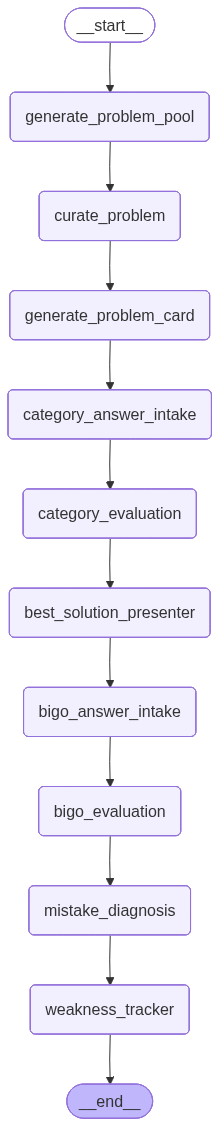

In [24]:
def build_graph():
    g = StateGraph(LearningState)

    # nodes
    g.add_node("generate_problem_pool", generate_problem_pool_node)
    g.add_node("curate_problem", problem_curation_node)
    g.add_node("generate_problem_card", problem_card_generator_node)

    g.add_node("category_answer_intake", category_answer_intake_node)
    g.add_node("category_evaluation", category_evaluation_node)

    g.add_node("best_solution_presenter", best_solution_presenter_node)

    g.add_node("bigo_answer_intake", bigo_answer_intake_node)
    g.add_node("bigo_evaluation", bigo_evaluation_node)

    g.add_node("mistake_diagnosis", mistake_diagnosis_node)
    g.add_node("weakness_tracker", weakness_tracker_node)

    # edges
    g.add_edge(START, "generate_problem_pool")
    g.add_edge("generate_problem_pool", "curate_problem")
    g.add_edge("curate_problem", "generate_problem_card")

    g.add_edge("generate_problem_card", "category_answer_intake")
    g.add_edge("category_answer_intake", "category_evaluation")
    g.add_edge("category_evaluation", "best_solution_presenter")

    g.add_edge("best_solution_presenter", "bigo_answer_intake")
    g.add_edge("bigo_answer_intake", "bigo_evaluation")

    g.add_edge("bigo_evaluation", "mistake_diagnosis")
    g.add_edge("mistake_diagnosis", "weakness_tracker")

    g.add_edge("weakness_tracker", END)

    return g.compile()


app = build_graph()

app

In [25]:
initial_state: LearningState = {
    "user_profile": DEFAULT_PROFILE,
    # Example: problems that should be prioritized for review
    "due_review_ids": ["lc_20_valid_parentheses"],

    # Simulated user answers (MCQ indices)
    # - Category: pick an option index from `category_mcq['options']`
    "category_selected_index": 0,

    # - Big-O: pick indices from the generated MCQ options
    "bigo_selected_time_index": 0,
    "bigo_selected_space_index": 0,
}

final_state = app.invoke(initial_state)

{
    "selected_problem": final_state["selected_problem"],
    "category_mcq": final_state["category_mcq"],
    "category_selected": final_state["category_selected"],
    "expected_category": final_state.get("expected_category"),
    "category_is_correct": final_state.get("category_is_correct"),
    "expected_bigo": {
        "time": final_state.get("expected_bigo_time"),
        "space": final_state.get("expected_bigo_space"),
    },
    "bigo_mcq_time": final_state["bigo_mcq_time"],
    "bigo_mcq_space": final_state["bigo_mcq_space"],
    "bigo_selected": {
        "time": final_state.get("bigo_selected_time"),
        "space": final_state.get("bigo_selected_space"),
    },
    "bigo_is_correct": final_state.get("bigo_is_correct"),
    "mistake_diagnosis": final_state.get("mistake_diagnosis"),
    "updated_weakness": final_state["user_profile"]["weakness_by_category"],
}


{'selected_problem': {'id': 'lc_three_sum',
  'title': '3Sum',
  'slug': '3sum',
  'url': 'https://leetcode.com/problems/3sum/',
  'categories': ['array', 'two_pointers'],
  'difficulty': 'Medium',
  'interview_freq': 0.85},
 'category_mcq': {'prompt': 'Select the best primary solution category for: 3Sum',
  'options': ['sorting', 'two_pointers', 'greedy', 'array', 'binary_search']},
 'category_selected': 'sorting',
 'expected_category': 'array',
 'category_is_correct': False,
 'expected_bigo': {'time': 'O(n^2)', 'space': 'O(n)'},
 'bigo_mcq_time': {'prompt': 'Select the expected TIME complexity of the optimal solution:',
  'options': ['O(n log n)', 'O(n^2)', 'O(n)', 'O(1)', 'O(n^3)']},
 'bigo_mcq_space': {'prompt': 'Select the expected SPACE complexity of the optimal solution:',
  'options': ['O(log n)', 'O(n^2)', 'O(n)', 'O(2^n)', 'O(1)']},
 'bigo_selected': {'time': 'O(n log n)', 'space': 'O(log n)'},
 'bigo_is_correct': False,
 'mistake_diagnosis': {'category': {'selected': 'sortin

## TBD

    WEAK --> SR[Spaced Repetition Scheduler]

    SR --> WRONG[Wrong Note Update]
    SR --> NEXT[Next Problem Selector]

    WRONG --> UPDATE[Update User Learning State]
    NEXT --> UPDATE

    UPDATE --> CONT{Continue Session?}
    CONT -- Yes --> CURATE
    CONT -- No --> END([END])
```

## Notes
- The diagram above matches the **full target design** (including spaced repetition + branching + looping).
- In this notebook implementation, the **core path up to `Weakness Tracker` is implemented**; the remaining nodes are design targets you can add next.
- Intake nodes are MCQ by design; the notebook simulates user choices via `category_selected_index`, `bigo_selected_time_index`, and `bigo_selected_space_index`.
